# ML-Based Vehicle Fuel Efficiency Prediction

**Data Source:** [EPA Fuel Economy Testing Data](https://www.epa.gov/compliance-and-fuel-economy-data/data-cars-used-testing-fuel-economy)

## Objectives
- Develop a predictive model for estimating vehicle fuel efficiency (MPG) using machine learning
- Analyze how mechanical parameters (weight, horsepower, displacement) affect fuel consumption
- Set up a data-driven approach for improving automotive energy efficiency


## 1. Importing Libraries and Loading Dataset

This section imports required libraries and loads the dataset from an online source.
The dataset contains various automobile attributes used to predict fuel efficiency.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

# Load dataset directly from online source
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/mpg.csv"

df = pd.read_csv(url)
print("Dataset loaded successfully:", df.shape)
df.head()

Dataset loaded successfully: (398, 9)


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


## Dataset Overview

This section provides a summary of the dataset including its dimensions, data types, and statistical properties.  
Understanding the structure of the dataset is important before applying any preprocessing or modeling techniques.

In [2]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    object 
 8   name          398 non-null    object 
dtypes: float64(4), int64(3), object(2)
memory usage: 28.1+ KB


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
count,398.000000,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.469388,2970.424623,15.568090,76.010050
std,7.815984,1.701004,104.269838,38.491160,846.841774,2.757689,3.697627
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000
25%,17.500000,4.000000,104.250000,75.000000,2223.750000,13.825000,73.000000
50%,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000
75%,29.000000,8.000000,262.000000,126.000000,3608.000000,17.175000,79.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000


## Feature Understanding

This section examines categorical features such as vehicle origin and model year.  
Analyzing unique values helps in understanding the diversity and distribution of the dataset.

In [3]:
print("Unique Origin values:", df['origin'].unique())
print("Unique Model Years:", df['model_year'].unique())

Unique Origin values: ['usa' 'japan' 'europe']
Unique Model Years: [70 71 72 73 74 75 76 77 78 79 80 81 82]


## 2. Data Cleaning and Preprocessing

Real-world datasets often contain missing or inconsistent values.  
In this step, missing values are identified and handled appropriately.  

The horsepower column is converted to numeric format, and rows with missing values are removed to ensure data quality.  
This step ensures that the dataset is clean and suitable for machine learning models.

In [4]:
# --- Data Cleaning for MPG Dataset ---

# Check missing values
print("Missing values before cleaning:\n", df.isnull().sum())

# Convert horsepower to numeric (important fix)
df['horsepower'] = pd.to_numeric(df['horsepower'], errors='coerce')

# Drop rows with missing values
df = df.dropna()

# Reset index (clean look)
df = df.reset_index(drop=True)

# Final check
print("\nMissing values after cleaning:\n", df.isnull().sum())
print("\nCleaned dataset shape:", df.shape)
print("\nColumns in dataset:", df.columns.tolist())
df.head()

Missing values before cleaning:
 mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
name            0
dtype: int64

Missing values after cleaning:
 mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model_year      0
origin          0
name            0
dtype: int64

Cleaned dataset shape: (392, 9)

Columns in dataset: ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year', 'origin', 'name']


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


## Feature Engineering

A new feature called **power-to-weight ratio** is created using horsepower and vehicle weight.  

This feature represents an important mechanical characteristic, as it directly relates engine power to vehicle mass.  
Including this feature helps improve the model's ability to capture real-world vehicle performance behavior.

In [5]:
# Create new feature
df['power_to_weight'] = df['horsepower'] / df['weight']

# Check
df[['horsepower','weight','power_to_weight']].head()

,horsepower,weight,power_to_weight
0,130.0,3504,0.037100
1,165.0,3693,0.044679
2,150.0,3436,0.043655
3,150.0,3433,0.043694
4,140.0,3449,0.040591


## 3. Exploratory Data Analysis (EDA)

In this section, relationships between key variables are analyzed using visualizations.  

The goal is to understand how mechanical parameters such as horsepower, displacement, weight, and number of cylinders affect fuel efficiency.  
Only the most relevant plots are used to avoid redundancy while maintaining clarity.

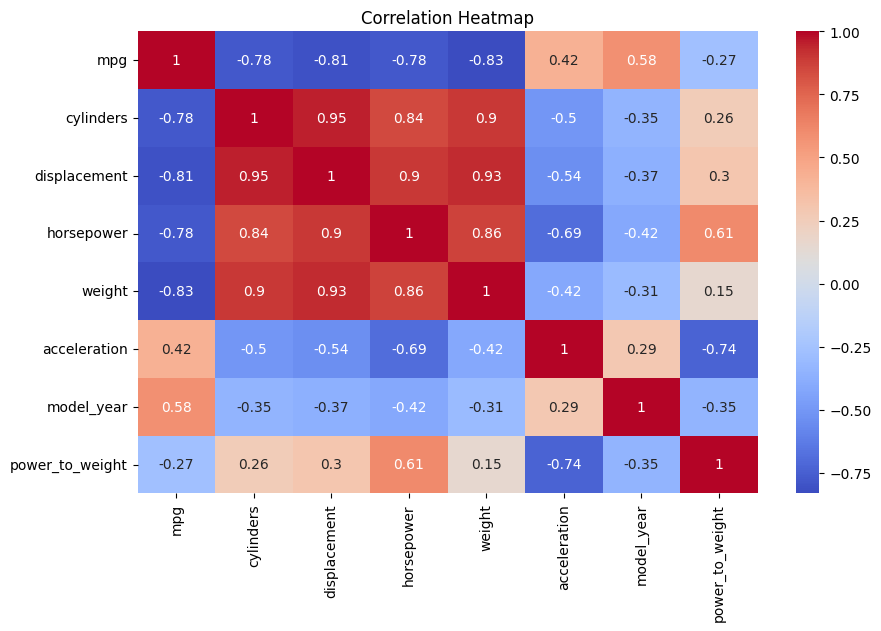

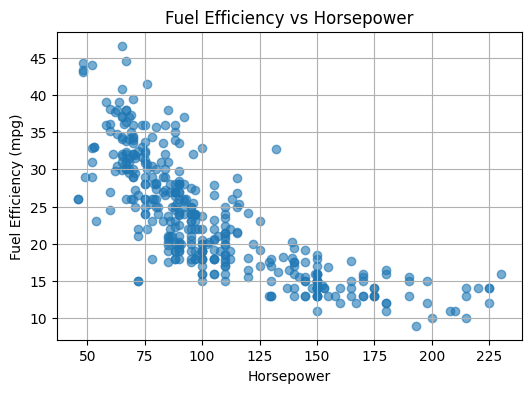

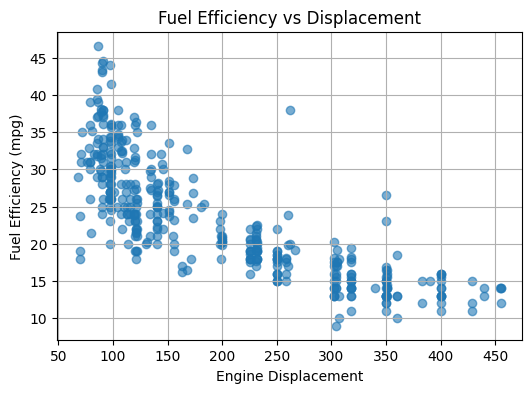

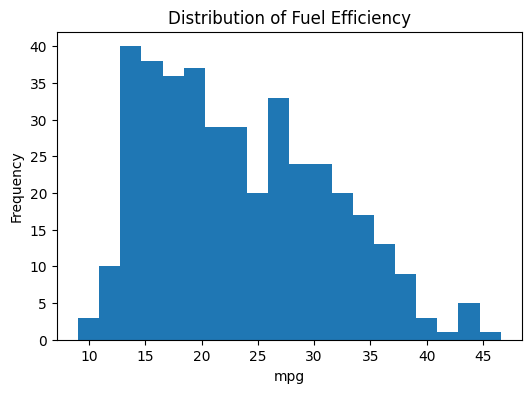

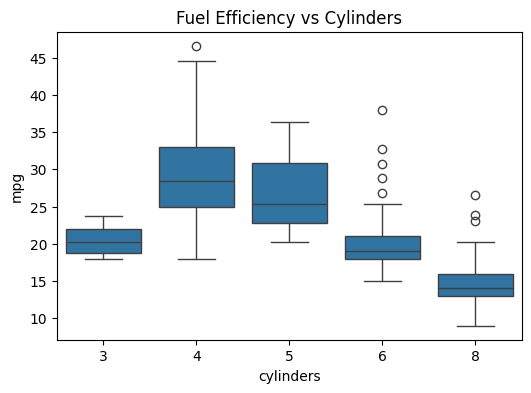

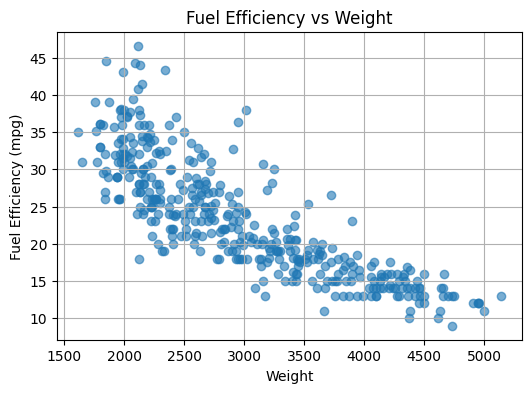

In [6]:
# --- Exploratory Data Analysis (MPG Dataset) ---

# 1. Correlation Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.select_dtypes(include=['float64','int64']).corr(), cmap='coolwarm', annot=True)
plt.title("Correlation Heatmap")
plt.show()


# 2. Horsepower vs Fuel Efficiency
plt.figure(figsize=(6,4))
plt.scatter(df['horsepower'], df['mpg'], alpha=0.6)
plt.xlabel("Horsepower")
plt.ylabel("Fuel Efficiency (mpg)")
plt.title("Fuel Efficiency vs Horsepower")
plt.grid()
plt.show()


# 3. Displacement vs Fuel Efficiency
plt.figure(figsize=(6,4))
plt.scatter(df['displacement'], df['mpg'], alpha=0.6)
plt.xlabel("Engine Displacement")
plt.ylabel("Fuel Efficiency (mpg)")
plt.title("Fuel Efficiency vs Displacement")
plt.grid()
plt.show()


# 4. Fuel Efficiency Distribution
plt.figure(figsize=(6,4))
plt.hist(df['mpg'], bins=20)
plt.title("Distribution of Fuel Efficiency")
plt.xlabel("mpg")
plt.ylabel("Frequency")
plt.show()

# 5. Boxplot: Cylinders vs MPG
plt.figure(figsize=(6,4))
sns.boxplot(x=df['cylinders'], y=df['mpg'])
plt.title("Fuel Efficiency vs Cylinders")
plt.show()

# 6. Weight vs MPG
plt.figure(figsize=(6,4))
plt.scatter(df['weight'], df['mpg'], alpha=0.6)
plt.xlabel("Weight")
plt.ylabel("Fuel Efficiency (mpg)")
plt.title("Fuel Efficiency vs Weight")
plt.grid()
plt.show()

## Observations from EDA

- Fuel efficiency decreases as horsepower and vehicle weight increase.  
- Larger engine displacement results in higher fuel consumption.  
- Vehicles with fewer cylinders tend to have better mileage.  
- Strong negative correlation exists between weight and fuel efficiency.  

These insights confirm expected mechanical relationships between engine performance and fuel consumption.

## 4. Model Development

In this section, machine learning models are developed to predict fuel efficiency.  

Three models are used:
- Linear Regression: baseline model for linear relationships  
- Decision Tree: captures non-linear patterns  
- Random Forest: ensemble method for improved accuracy  

The dataset is split into training and testing sets, and feature scaling is applied to improve model performance.

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# --- Feature Selection (MPG dataset) ---
features = ['displacement', 'horsepower', 'weight', 'cylinders', 'power_to_weight']

X = df[features]
y = df['mpg']   # Target variable

# --- Train-Test Split ---
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# --- Define Models ---
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(max_depth=5),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42)
}

# --- Training and Evaluation ---
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    mse = mean_squared_error(y_test, preds)
    r2 = r2_score(y_test, preds)

    results[name] = (mse, r2)

    print("\n", name)
    print("Mean Squared Error (MSE):", round(mse, 2))
    print("R2 Score:", round(r2, 3))


 Linear Regression
Mean Squared Error (MSE): 17.08
R2 Score: 0.665

 Decision Tree
Mean Squared Error (MSE): 27.94
R2 Score: 0.453

 Random Forest
Mean Squared Error (MSE): 16.71
R2 Score: 0.673


## Model Comparison

The performance of different models is compared using evaluation metrics such as Mean Squared Error (MSE) and R² score.  

This comparison helps in identifying the most suitable model for predicting fuel efficiency.

                         MSE        R2
Linear Regression  17.083223  0.665301
Decision Tree      27.942253  0.452548
Random Forest      16.707387  0.672665


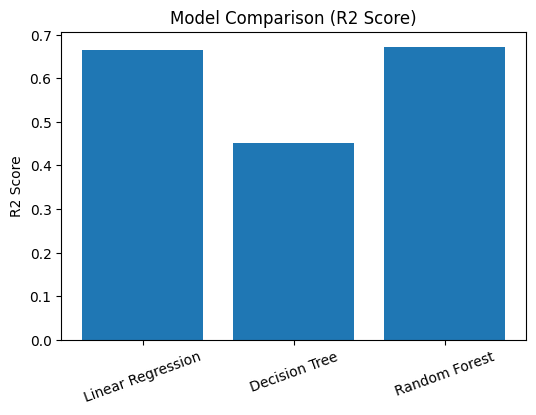

In [8]:
results_df = pd.DataFrame(results, index=["MSE", "R2"]).T
print(results_df)
plt.figure(figsize=(6,4))
plt.bar(results_df.index, results_df['R2'])
plt.title("Model Comparison (R2 Score)")
plt.ylabel("R2 Score")
plt.xticks(rotation=20)
plt.show()

## Feature Importance Analysis

This section identifies the most influential features affecting fuel efficiency using the Random Forest model.  

Understanding feature importance provides insights into which mechanical parameters play a dominant role in fuel consumption.

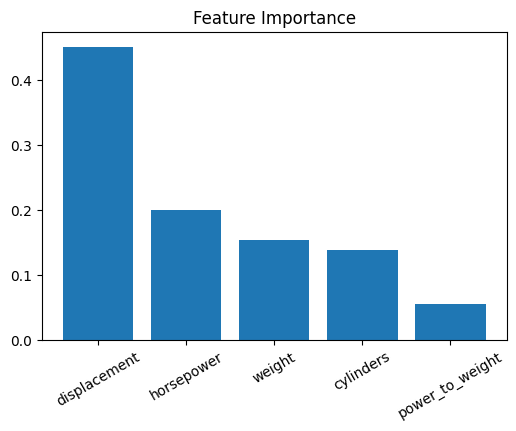

In [9]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

importances = rf.feature_importances_

plt.figure(figsize=(6,4))
plt.bar(features, importances)
plt.title("Feature Importance")
plt.xticks(rotation=30)
plt.show()

## 5. Prediction and Analysis

The trained model is used to predict fuel efficiency on test data.  

Predicted values are compared with actual values using scatter plots, and model errors are analyzed using residual and error distribution plots.  
This helps in evaluating the accuracy and reliability of the model.

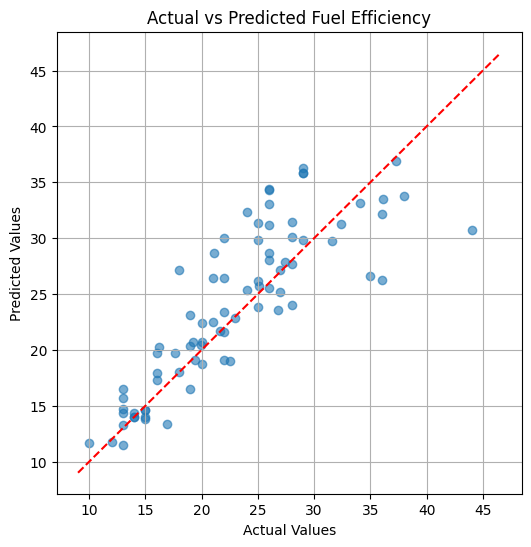

In [10]:
model = RandomForestRegressor(n_estimators=100)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')  # reference line
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Fuel Efficiency")
plt.grid()
plt.show()

## Residual Analysis

This plot shows the residuals, which are the differences between actual and predicted fuel efficiency values, plotted against the predicted values.

Residual analysis helps in evaluating the model performance by checking whether the errors are randomly distributed.  
A good model will have residuals scattered randomly around zero, indicating that the model captures the underlying pattern without systematic bias.

If patterns or trends appear in the residual plot, it may indicate that the model is missing important relationships or features.

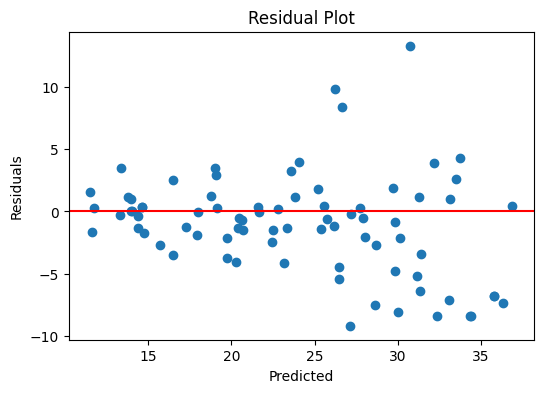

In [11]:
plt.figure(figsize=(6,4))
plt.scatter(y_pred, y_test - y_pred)
plt.axhline(0, color='red')
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

The residuals are distributed randomly around zero, suggesting that the model does not exhibit significant bias and performs reasonably well across different prediction ranges.

## Error Distribution Analysis

This section analyzes the distribution of prediction errors, where error is defined as the difference between actual and predicted fuel efficiency values.

A well-performing model should have errors centered around zero, indicating that predictions are neither consistently overestimated nor underestimated.  
The spread of the error distribution provides insight into model accuracy and variability.

This analysis helps evaluate the reliability of the model and identify any bias in predictions.

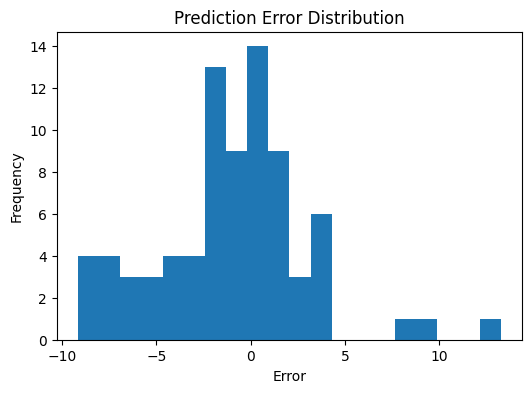

In [12]:
errors = y_test - y_pred

plt.figure(figsize=(6,4))
plt.hist(errors, bins=20)
plt.title("Prediction Error Distribution")
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.show()

## Final Conclusion

- Random Forest model achieved the best performance among all models.  
- Fuel efficiency is strongly influenced by weight, horsepower, and engine displacement.  
- Feature engineering (power-to-weight ratio) improved model understanding.  
- Feature importance analysis highlights key mechanical parameters.  
- The model successfully captures both linear and non-linear relationships in vehicle data.  

This approach demonstrates how machine learning can be applied to optimize vehicle performance and improve energy efficiency in automotive engineering.